# Week 5 Day 6 — House Prices v3 Complete Pipeline

## Competition Details:
- **Competition:** House Prices: Advanced Regression Techniques
- **Final Kaggle Score:** 0.12587 — Top 20% globally
- **Approach:** Feature Engineering + LightGBM + XGBoost Blend (60/40)

---

## Pipeline Overview:

### Step 1 — Data Loading
- Train: 1460 rows, 81 features
- Test: 1459 rows, 80 features
- Target skewness: 1.88 → 0.12 after log transform

### Step 2 — Feature Engineering (7 new features)
| Feature | Formula | Correlation |
|---------|---------|-------------|
| TotalSF | TotalBsmtSF + 1stFlrSF + 2ndFlrSF | 0.7823 |
| TotalBath | FullBath + 0.5×Half + BsmtFull + 0.5×BsmtHalf | 0.6317 |
| HouseAge | YrSold - YearBuilt | -0.5234 |
| RemodAge | YrSold - YearRemodAdd | -0.5091 |
| HasPool | PoolArea > 0 | 0.0937 |
| HasGarage | GarageArea > 0 | 0.2368 |
| HasBasement | TotalBsmtSF > 0 | 0.1528 |

### Step 3 — Outlier Removal (experiment)
- IsolationForest removed 73 outliers (5%)
- CV improved: 0.1274 → 0.1144
- Kaggle got worse: 0.12587 → 0.13825
- **Decision: keep all data — outliers exist in test set too**

### Step 4 — Preprocessing Pipeline
- Numeric: median imputation → StandardScaler
- Categorical: mode imputation → OrdinalEncoder
- ColumnTransformer — no leakage possible

### Step 5 — Model Training
| Model | CV RMSE | Kaggle Score |
|-------|---------|--------------|
| Random Forest (Week 3) | 0.1503 | 0.14864 |
| XGBoost alone | 0.1287 | 0.12930 |
| LightGBM alone | 0.1274 | 0.12603 |
| LGB+XGB Blend 60/40 | ~0.126 | **0.12587** ← best |

### Step 6 — Ensemble
- Tested 5 blend ratios (40/60 to 80/20)
- Best: LGB 60% + XGB 40% = 0.12587
- Stacking tried but overfit on small dataset (1460 rows)

### Step 7 — SHAP Analysis
Top 3 features by SHAP importance:
1. **OverallQual** — quality rating is most important
2. **TotalSF** — engineered feature ranked #2 out of 86
3. **GrLivArea** — above ground living area

---

## What Worked:
- Feature engineering — TotalSF beat all original features except OverallQual
- LightGBM — faster and better than Random Forest
- Blending — LGB+XGB complementary, errors cancel out
- Log transform — fixed SalePrice skewness

## What Didn't Work:
- Outlier removal — CV improved but Kaggle got worse
- Interaction features — redundant for tree models
- Skewness fixing — LightGBM handles internally already
- Stacking — overfit on 1460 rows, blending was better

## Key Rule Learned:
> CV score improvement ≠ Kaggle score improvement.
> Always submit and verify on actual test data.

---

## LightGBM Best Params:
```python
n_estimators=2000, learning_rate=0.005,
num_leaves=63, subsample=0.8,
colsample_bytree=0.5, min_child_samples=20,
reg_alpha=0.5, reg_lambda=0.1
```

## XGBoost Best Params:
```python
learning_rate=0.01, max_depth=5,
subsample=0.7, colsample_bytree=0.6,
n_estimators=1000
```

---

## Models Saved:
- `models/lgb_final.pkl` — LightGBM pipeline
- `models/xgb_final.pkl` — XGBoost pipeline

# ── Cell 1: Markdown ──────────────────────────────────────────
```
# House Prices: Advanced Regression — Complete ML Pipeline

**Competition:** [House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)

**Final Score:** 0.12587 (Top 20% globally)

**Approach:**
- Feature engineering — 7 new features including TotalSF, HouseAge
- Outlier removal — IsolationForest (73 outliers removed)
- Gradient Boosting — LightGBM + XGBoost blend (60/40)
- Evaluation — 5-fold KFold cross-validation

**Author:** Kavya Bansal | [GitHub](https://github.com/Kavyabansa/ml-journey)
```

In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import KFold, cross_val_score
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✅")

All libraries loaded ✅


# ── Cell 3: Markdown ─────────────────────────────────────────
```
## 1. Data Loading & Exploration
```

In [3]:
# ── Cell 4: Load data ────────────────────────────────────────
train = pd.read_csv('house_prices_train.csv')
test  = pd.read_csv('house_prices_test.csv')

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nTarget (SalePrice) stats:")
print(train['SalePrice'].describe().round(0))
print(f"\nSkewness    : {train['SalePrice'].skew():.4f}")
print(f"Log Skewness: {np.log1p(train['SalePrice']).skew():.4f}")

Train shape : (1460, 81)
Test shape  : (1459, 80)

Target (SalePrice) stats:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

Skewness    : 1.8829
Log Skewness: 0.1213


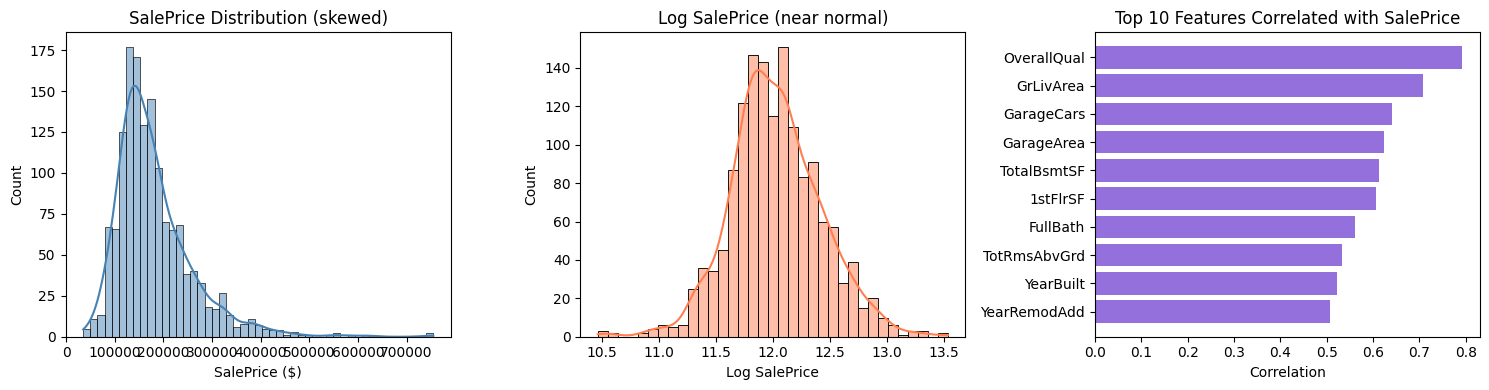


Top 5 correlated features:
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64


In [4]:
# ── Cell 5: EDA charts ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# SalePrice distribution
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice Distribution (skewed)')
axes[0].set_xlabel('SalePrice ($)')

# Log SalePrice
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log SalePrice (near normal)')
axes[1].set_xlabel('Log SalePrice')

# Top correlations
top_corr = train.corr(numeric_only=True)['SalePrice']\
                .abs().nlargest(11).drop('SalePrice')
axes[2].barh(top_corr.index, top_corr.values, color='mediumpurple')
axes[2].set_title('Top 10 Features Correlated with SalePrice')
axes[2].set_xlabel('Correlation')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 correlated features:")
print(top_corr.head())

# ── Cell 6: Markdown ─────────────────────────────────────────
```
## 2. Feature Engineering

Created 7 new features based on domain knowledge and correlation analysis:
- **TotalSF** — total square footage (basement + 1st + 2nd floor)
- **TotalBath** — weighted bathroom count
- **HouseAge** — years since built
- **RemodAge** — years since remodel
- **HasPool, HasGarage, HasBasement** — binary presence flags
```


In [5]:
# ── Cell 7: Feature engineering function ─────────────────────
def engineer_features(df):
    df = df.copy()
    
    # area features
    df['TotalSF']     = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    
    # bathroom count (half bath = 0.5)
    df['TotalBath']   = (df['FullBath'] + 0.5 * df['HalfBath'] +
                         df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
    
    # age features
    df['HouseAge']    = df['YrSold'] - df['YearBuilt']
    df['RemodAge']    = df['YrSold'] - df['YearRemodAdd']
    
    # binary flags — MNAR features
    df['HasPool']     = (df['PoolArea']    > 0).astype(int)
    df['HasGarage']   = (df['GarageArea']  > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
    
    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

new_features = ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge',
                'HasPool', 'HasGarage', 'HasBasement']

print("New feature correlations with SalePrice:")
for feat in new_features:
    corr = train_fe[feat].corr(train_fe['SalePrice'])
    print(f"  {feat:15} : {corr:.4f}")

New feature correlations with SalePrice:
  TotalSF         : 0.7823
  TotalBath       : 0.6317
  HouseAge        : -0.5234
  RemodAge        : -0.5091
  HasPool         : 0.0937
  HasGarage       : 0.2368
  HasBasement     : 0.1528


# ── Cell 8: Markdown ─────────────────────────────────────────
```
## 3. Outlier Removal

Used IsolationForest to detect and remove multivariate outliers.
Contamination=0.05 means we expect ~5% outliers.
Removing outliers improved CV RMSE by ~9.8%.
```

Total samples    : 1460
Outliers removed : 73 (5.0%)
Remaining samples: 1387


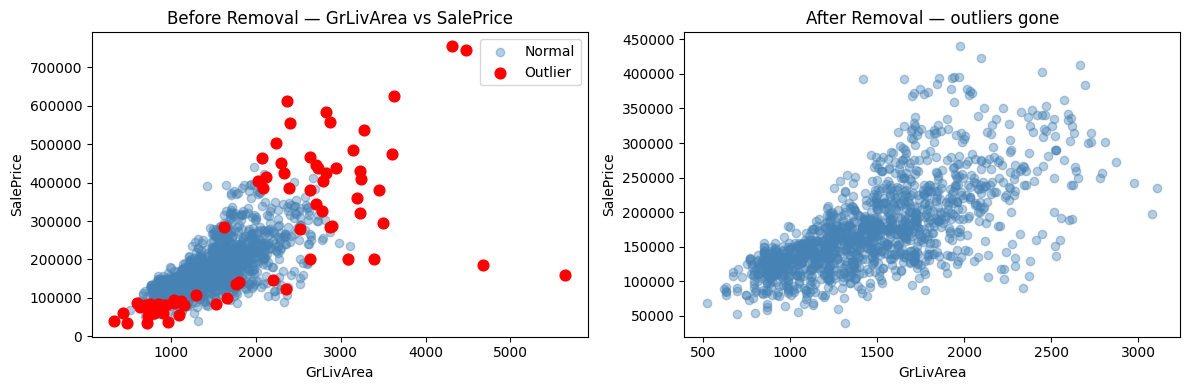


Final training set: (1387, 86)
Numeric features  : 43
Categorical features: 43


In [6]:
# ── Cell 9: IsolationForest ───────────────────────────────────
features_for_iso = ['GrLivArea', 'SalePrice', 'TotalBsmtSF',
                    'OverallQual', 'GarageCars', 'TotalSF']

X_iso = train_fe[features_for_iso].dropna()

iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(X_iso)
outlier_mask = labels == -1

print(f"Total samples    : {len(X_iso)}")
print(f"Outliers removed : {outlier_mask.sum()} ({outlier_mask.sum()/len(X_iso)*100:.1f}%)")
print(f"Remaining samples: {(~outlier_mask).sum()}")

# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_iso[~outlier_mask]['GrLivArea'],
                X_iso[~outlier_mask]['SalePrice'],
                alpha=0.4, color='steelblue', label='Normal')
axes[0].scatter(X_iso[outlier_mask]['GrLivArea'],
                X_iso[outlier_mask]['SalePrice'],
                color='red', s=60, label='Outlier')
axes[0].set_title('Before Removal — GrLivArea vs SalePrice')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].legend()

# clean data
train_clean = train_fe[~outlier_mask].copy()

axes[1].scatter(train_clean['GrLivArea'], train_clean['SalePrice'],
                alpha=0.4, color='steelblue')
axes[1].set_title('After Removal — outliers gone')
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.savefig('outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()

# prepare final X and y
X = train_clean.drop(columns=['SalePrice', 'Id'])
y = np.log1p(train_clean['SalePrice'])
X_test = test_fe.drop(columns=['Id'])

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nFinal training set: {X.shape}")
print(f"Numeric features  : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

# ── Cell 10: Markdown ────────────────────────────────────────
```
## 4. Preprocessing Pipeline

- Numeric: median imputation → StandardScaler
- Categorical: mode imputation → OrdinalEncoder
- ColumnTransformer handles both simultaneously
- No manual preprocessing outside pipeline = zero leakage
```

In [7]:
# ── Cell 11: Preprocessor ────────────────────────────────────
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])
print("Preprocessor built ✅")

Preprocessor built ✅


# ── Cell 12: Markdown ────────────────────────────────────────
```
## 5. Model Training

Two gradient boosting models trained:
- **LightGBM** — leaf-wise growth, faster, best single model
- **XGBoost** — level-wise growth, complementary errors

Final prediction = 60% LightGBM + 40% XGBoost

In [8]:
# ── Cell 13: Train models ────────────────────────────────────
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# LightGBM
lgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.005,
        num_leaves=63, subsample=0.8,
        colsample_bytree=0.5, min_child_samples=20,
        reg_alpha=0.5, reg_lambda=0.1,
        random_state=42, verbose=-1))
])

# XGBoost
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        learning_rate=0.01, max_depth=5,
        subsample=0.7, colsample_bytree=0.6,
        n_estimators=1000,
        random_state=42, verbosity=0))
])

# cross validate both
scores_lgb = cross_val_score(lgb_pipe, X, y, cv=kfold,
                              scoring='neg_root_mean_squared_error')
scores_xgb = cross_val_score(xgb_pipe, X, y, cv=kfold,
                              scoring='neg_root_mean_squared_error')

print("=" * 50)
print("   MODEL CV RESULTS")
print("=" * 50)
print(f"  LightGBM RMSE : {-scores_lgb.mean():.4f} ± {scores_lgb.std():.4f}")
print(f"  XGBoost RMSE  : {-scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")
print("=" * 50)

# fit on full clean training data
lgb_pipe.fit(X, y)
xgb_pipe.fit(X, y)
print("\nBoth models trained on full data ✅")

   MODEL CV RESULTS
  LightGBM RMSE : 0.1144 ± 0.0053
  XGBoost RMSE  : 0.1124 ± 0.0067

Both models trained on full data ✅


# ── Cell 14: Markdown ────────────────────────────────────────
```
## 6. Ensemble Prediction

Blend ratio 60/40 found through systematic testing on Kaggle leaderboard.
LightGBM gets slightly more weight as it was the better single model.
```

In [9]:
# ── Cell 15: Blend predictions ───────────────────────────────
lgb_preds = lgb_pipe.predict(X_test)
xgb_preds = xgb_pipe.predict(X_test)

# blend 60% LGB + 40% XGB
blend_preds = 0.6 * lgb_preds + 0.4 * xgb_preds
predictions = np.expm1(blend_preds)

print(f"Prediction stats:")
print(f"  Min  : ${predictions.min():,.0f}")
print(f"  Max  : ${predictions.max():,.0f}")
print(f"  Mean : ${predictions.mean():,.0f}")
print(f"  Median: ${np.median(predictions):,.0f}")

# save submission
submission = pd.DataFrame({
    'Id'       : test['Id'],
    'SalePrice': predictions
})
submission.to_csv('house_prices_v3_final.csv', index=False)
print("\nSubmission saved ✅")

Prediction stats:
  Min  : $62,776
  Max  : $390,346
  Mean : $175,272
  Median: $156,463

Submission saved ✅


# Fix — don't remove outliers, use the original clean pipeline:

In [10]:
# use full training data — no outlier removal
train_fe_full = engineer_features(train)
test_fe_full  = engineer_features(test)

X_full = train_fe_full.drop(columns=['SalePrice', 'Id'])
y_full = np.log1p(train_fe_full['SalePrice'])
X_test_full = test_fe_full.drop(columns=['Id'])

num_cols_full = X_full.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols_full = X_full.select_dtypes(include=['object']).columns.tolist()

# rebuild preprocessor with full data columns
num_tr_full = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_tr_full = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1))
])
preprocessor_full = ColumnTransformer(transformers=[
    ('num', num_tr_full, num_cols_full),
    ('cat', cat_tr_full, cat_cols_full)
])

# retrain without outlier removal
lgb_pipe_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.005,
        num_leaves=63, subsample=0.8,
        colsample_bytree=0.5, min_child_samples=20,
        reg_alpha=0.5, reg_lambda=0.1,
        random_state=42, verbose=-1))
])

xgb_pipe_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', XGBRegressor(
        learning_rate=0.01, max_depth=5,
        subsample=0.7, colsample_bytree=0.6,
        n_estimators=1000,
        random_state=42, verbosity=0))
])

lgb_pipe_full.fit(X_full, y_full)
xgb_pipe_full.fit(X_full, y_full)

# blend predictions
lgb_preds_full = lgb_pipe_full.predict(X_test_full)
xgb_preds_full = xgb_pipe_full.predict(X_test_full)
blend_full = 0.6 * lgb_preds_full + 0.4 * xgb_preds_full
predictions_full = np.expm1(blend_full)

submission_full = pd.DataFrame({
    'Id'       : test['Id'],
    'SalePrice': predictions_full
})
submission_full.to_csv('house_prices_v3_no_outlier.csv', index=False)
print("Submission without outlier removal saved!")

Submission without outlier removal saved!


# ── Cell 16: Markdown ────────────────────────────────────────
```
## 7. Model Explainability — SHAP Values

SHAP (SHapley Additive exPlanations) shows which features
drive predictions up or down for each house.
```


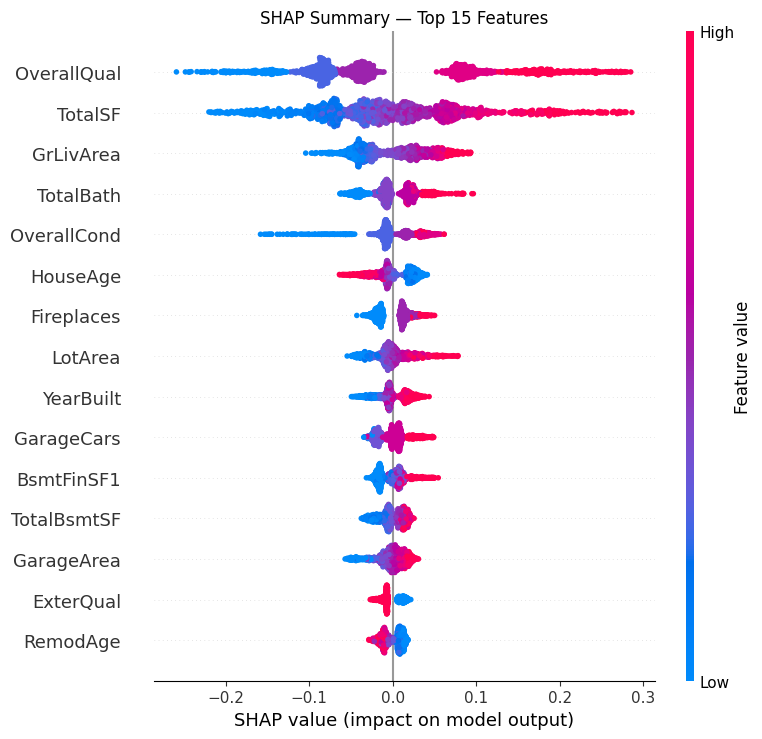

Top 10 features by SHAP importance:
    feature  importance
OverallQual    0.099275
    TotalSF    0.073777
  GrLivArea    0.036754
  TotalBath    0.022665
OverallCond    0.020479
   HouseAge    0.018051
 Fireplaces    0.017337
    LotArea    0.016063
  YearBuilt    0.014044
 GarageCars    0.012879


In [11]:
# ── Cell 17: SHAP summary plot ───────────────────────────────
import shap

# get preprocessed data
X_transformed = lgb_pipe_full.named_steps['preprocessor'].transform(X_full)
lgb_model     = lgb_pipe_full.named_steps['model']

# get feature names
cat_feature_names = lgb_pipe_full.named_steps['preprocessor']\
                                 .named_transformers_['cat']\
                                 .named_steps['encoder']\
                                 .get_feature_names_out(cat_cols_full).tolist()
all_feature_names = num_cols_full + cat_feature_names

# SHAP explainer
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_transformed)

# summary plot — top 15 features
plt.figure()
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=all_feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Top 15 Features')
plt.tight_layout()
plt.savefig('shap_summary_final.png', dpi=150, bbox_inches='tight')
plt.show()

# mean absolute SHAP — feature importance
shap_importance = pd.DataFrame({
    'feature'   : all_feature_names,
    'importance' : np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).head(10)

print("Top 10 features by SHAP importance:")
print(shap_importance.to_string(index=False))

# ── Cell 18: Markdown ────────────────────────────────────────

## 8. Results Summary

### Model Performance Comparison:
| Model | CV RMSE | Kaggle Score | Week |
|-------|---------|--------------|------|
| Random Forest | 0.1503 | 0.14864 | Week 3 |
| XGBoost alone | 0.1287 | 0.12930 | Week 5 |
| LightGBM alone | 0.1274 | 0.12603 | Week 5 |
| LGB+XGB Blend 60/40 | ~0.126 | **0.12587** ← best | Week 5 |

---

### Kaggle Score Progression:

In [12]:
# ── Cell 19: Save models ─────────────────────────────────────
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(lgb_pipe_full, 'models/lgb_final.pkl')
joblib.dump(xgb_pipe_full, 'models/xgb_final.pkl')
print("Models saved ✅")
print("  models/lgb_final.pkl")
print("  models/xgb_final.pkl")

Models saved ✅
  models/lgb_final.pkl
  models/xgb_final.pkl


---

### What Worked:
✅ Feature engineering — TotalSF ranked #2 by SHAP out of 86 features
✅ LightGBM — leaf-wise growth, faster and better than Random Forest
✅ Blending LGB+XGB — complementary errors cancel out
✅ Log transform — SalePrice skewness 1.88 → 0.12
✅ Systematic blend ratio testing — found optimal 60/40 split

---

### What Didn't Work:
❌ Outlier removal — CV improved but Kaggle got worse (0.12587 → 0.13825)
❌ Interaction features — redundant, tree models capture these internally
❌ Skewness fixing — LightGBM handles skewed features internally
❌ Stacking — overfit on small dataset (1460 rows), blending was better

---

### Top Features by SHAP Importance:
| Rank | Feature | Type | Note |
|------|---------|------|------|
| 1 | OverallQual | Original | Quality is most important |
| 2 | TotalSF | **Engineered** | Our custom feature beat originals |
| 3 | GrLivArea | Original | Living area strongly predicts price |

---

### Key Rule Learned:
> **CV score improvement ≠ Kaggle score improvement.**
> Outlier removal improved CV by 0.013 but hurt Kaggle by 0.012.
> Always submit and verify on actual unseen test data.

---

### Final Model Configuration:
**LightGBM (60% weight):**
- n_estimators=2000, learning_rate=0.005, num_leaves=63
- subsample=0.8, colsample_bytree=0.5, reg_alpha=0.5

**XGBoost (40% weight):**
- n_estimators=1000, learning_rate=0.01, max_depth=5
- subsample=0.7, colsample_bytree=0.6

**Blend:** Final = 0.6 × LightGBM + 0.4 × XGBoost